# Data Audit and Exploratory Data Analysis (EDA)

This notebook loads the raw datasets, conducts data-quality validation, and performs exploratory analysis to identify churn drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data')
%matplotlib inline


## 1. Load Datasets

In [2]:
dfs = {
    "customers": pd.read_csv(DATA / "customers.csv", parse_dates=["signup_date"]),
    "orders": pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"]),
    "tickets": pd.read_csv(DATA / "support_tickets.csv", parse_dates=["ticket_date"]),
    "web": pd.read_csv(DATA / "web_events_snapshot.csv", parse_dates=["snapshot_date"]),
    "labels": pd.read_csv(DATA / "churn_labels.csv", parse_dates=["snapshot_date"]),
    "snapshot": pd.read_csv(DATA / "rfm_modeling_snapshot.csv", parse_dates=["snapshot_date"]),
    "interventions": pd.read_csv(DATA / "intervention_history.csv", parse_dates=["snapshot_date"]),
}

for name, df in dfs.items():
    print(f"{name:15}: {df.shape[0]} rows, {df.shape[1]} columns")


customers      : 2400 rows, 9 columns
orders         : 10009 rows, 10 columns
tickets        : 1921 rows, 8 columns
web            : 2400 rows, 10 columns
labels         : 2400 rows, 4 columns
snapshot       : 2400 rows, 29 columns
interventions  : 2400 rows, 5 columns


## 2. Data Quality Audit
Check for duplicate records, missing values, outliers, and join issues.

In [3]:
# Duplicate check
for name, df in dfs.items():
    dups = df.duplicated().sum()
    print(f"{name:15} duplicates: {dups}")

# Missing value check
print("\nMissing values by dataset and column:")
for name, df in dfs.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"--- {name} ---")
        print(missing)


customers       duplicates: 0
orders          duplicates: 0
tickets         duplicates: 0
web             duplicates: 0
labels          duplicates: 0
snapshot        duplicates: 0
interventions   duplicates: 0

Missing values by dataset and column:
--- customers ---
loyalty_tier    1386
skin_type        401
dtype: int64
--- orders ---
rating    80
dtype: int64
--- snapshot ---
loyalty_tier    1386
dtype: int64


In [4]:
# Outlier detection using IQR
orders = dfs["orders"]
q1, q3 = orders["gross_amount"].quantile([0.25, 0.75])
iqr = q3 - q1
outlier_cutoff = q3 + 1.5 * iqr
outliers = orders[orders["gross_amount"] > outlier_cutoff]
print(f"Gross amount outliers cutoff: INR {outlier_cutoff:.2f}")
print(f"Number of outlier order records: {len(outliers)} (Max: INR {orders['gross_amount'].max():.2f})")


Gross amount outliers cutoff: INR 1619.30
Number of outlier order records: 536 (Max: INR 24789.38)


## 3. Exploratory Data Analysis & Visualizations

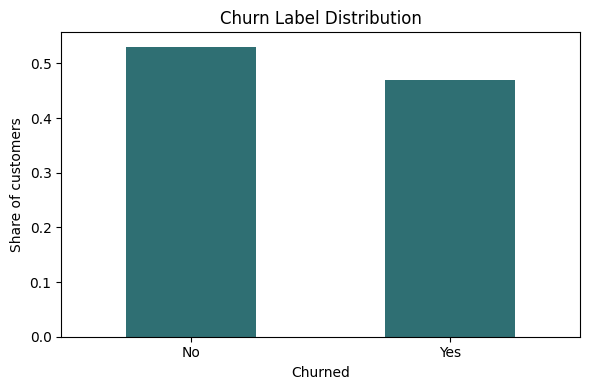

In [5]:
# 1. Churn label distribution
plt.figure(figsize=(6, 4))
dfs["labels"]["churn_next_60d"].value_counts(normalize=True).sort_index().plot(kind="bar", color="#2F6F73")
plt.title("Churn Label Distribution")
plt.xlabel("Churned")
plt.ylabel("Share of customers")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()


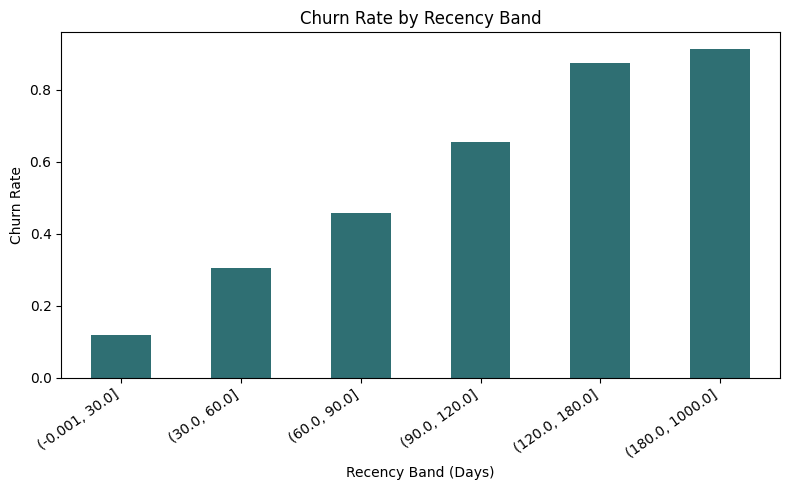

In [6]:
# 2. Churn rate by recency band
snap = dfs["snapshot"]
recency_bins = pd.cut(snap["recency_days"], [0, 30, 60, 90, 120, 180, 1000], include_lowest=True)
plt.figure(figsize=(8, 5))
snap.groupby(recency_bins, observed=False)["churn_next_60d"].mean().plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by Recency Band")
plt.xlabel("Recency Band (Days)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


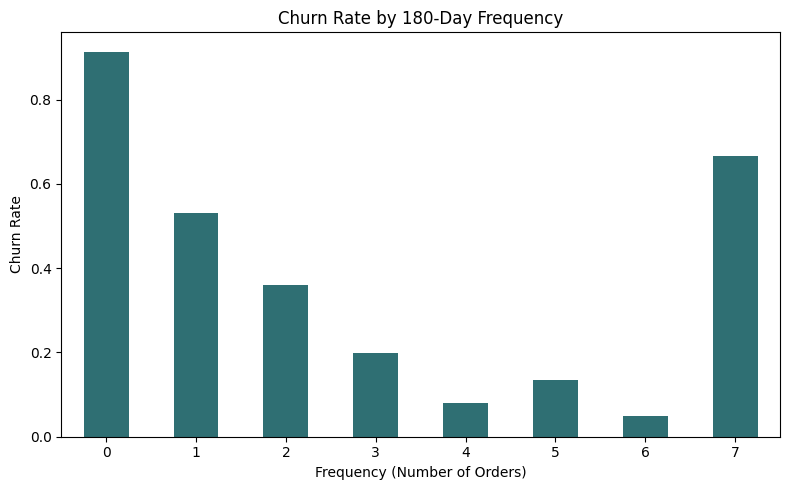

In [7]:
# 3. Churn rate by 180-Day Frequency
plt.figure(figsize=(8, 5))
snap.groupby("frequency_180d")["churn_next_60d"].mean().head(8).plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by 180-Day Frequency")
plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


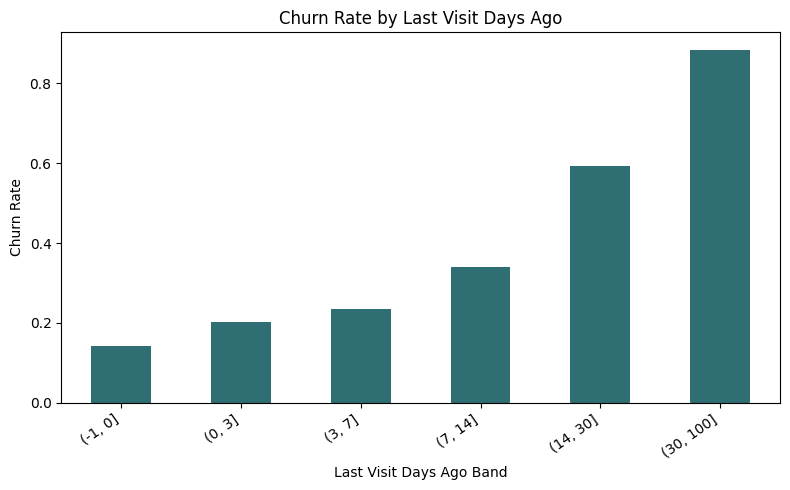

In [8]:
# 4. Churn rate by last visit days ago
visit_bins = pd.cut(snap["last_visit_days_ago"], [-1, 0, 3, 7, 14, 30, 100])
plt.figure(figsize=(8, 5))
snap.groupby(visit_bins, observed=False)["churn_next_60d"].mean().plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by Last Visit Days Ago")
plt.xlabel("Last Visit Days Ago Band")
plt.ylabel("Churn Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


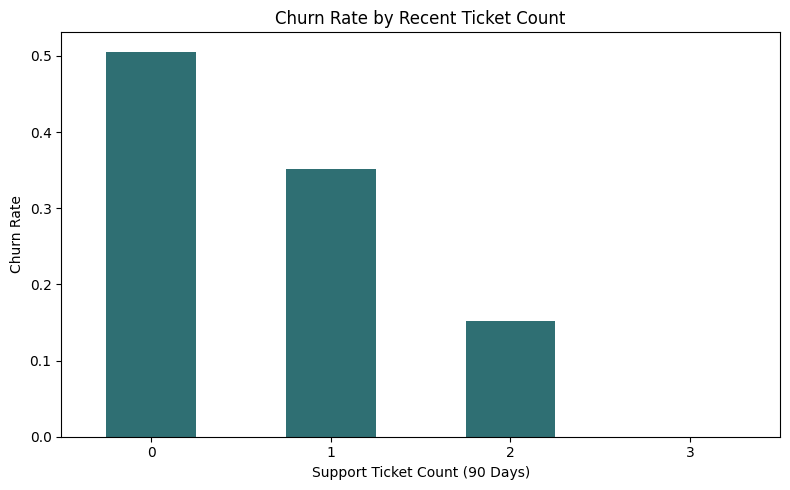

In [9]:
# 5. Churn rate by recent ticket count
plt.figure(figsize=(8, 5))
snap.groupby("ticket_count_90d")["churn_next_60d"].mean().head(6).plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by Recent Ticket Count")
plt.xlabel("Support Ticket Count (90 Days)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


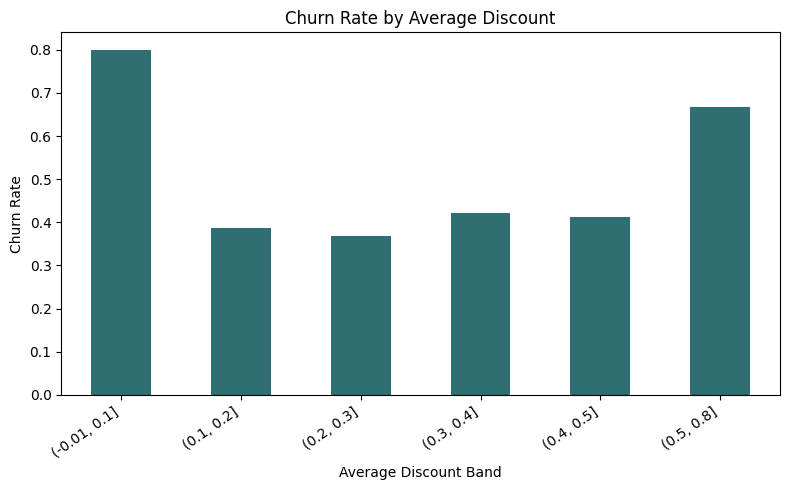

In [10]:
# 6. Churn rate by average discount
discount_bins = pd.cut(snap["avg_discount_pct_180d"], [-0.01, .1, .2, .3, .4, .5, .8])
plt.figure(figsize=(8, 5))
snap.groupby(discount_bins, observed=False)["churn_next_60d"].mean().plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by Average Discount")
plt.xlabel("Average Discount Band")
plt.ylabel("Churn Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


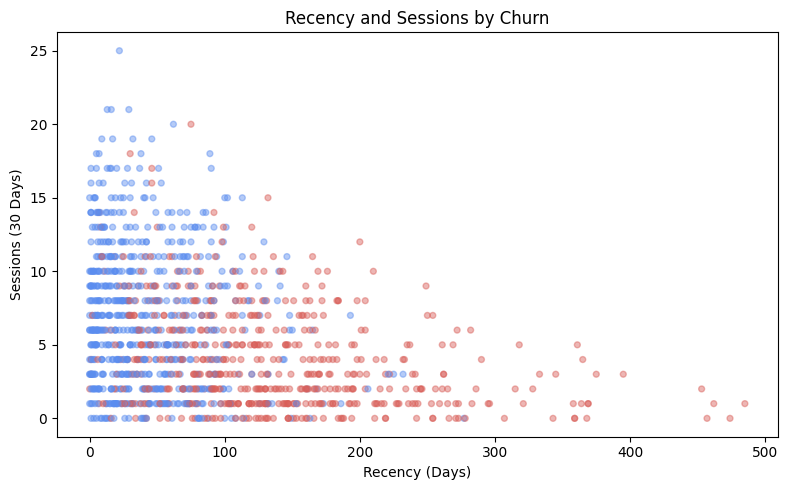

In [11]:
# 7. Scatter plot of recency vs sessions by churn
plt.figure(figsize=(8, 5))
sample = snap.sample(min(1200, len(snap)), random_state=7)
colors = sample["churn_next_60d"].map({0: "#5B8DEF", 1: "#D95F59"})
plt.scatter(sample["recency_days"], sample["sessions_30d"], c=colors, alpha=0.45, s=18)
plt.title("Recency and Sessions by Churn")
plt.xlabel("Recency (Days)")
plt.ylabel("Sessions (30 Days)")
plt.tight_layout()
plt.show()


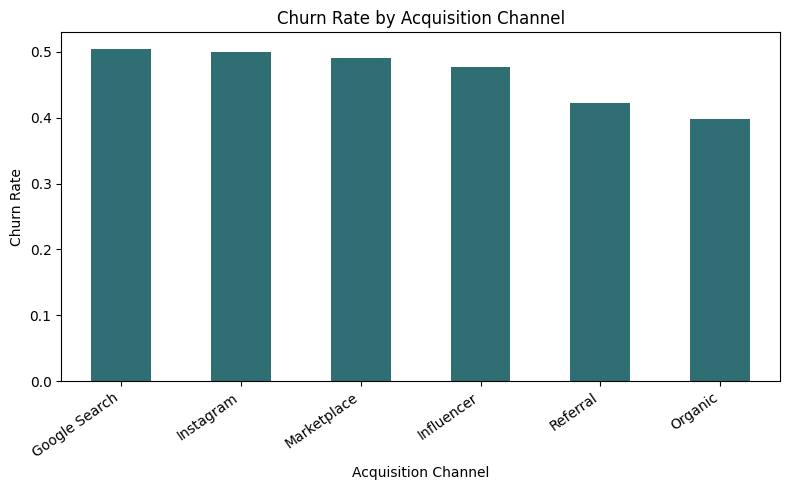

In [12]:
# 8. Churn rate by acquisition channel
cat_churn = dfs["customers"].merge(dfs["labels"], on="customer_id").groupby("acquisition_channel")["churn_next_60d"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
cat_churn.plot(kind="bar", color="#2F6F73")
plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Churn Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
